Dataset

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

%config InlineBackend.figure_format = "svg"

#Increase the default plotsize and set the color scheme
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["image.cmap"] = "viridis"

import pandas as pd

In [2]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

df = pd.read_csv(DATA_URL + "video_games_sales.csv").dropna() #drops rows with NaN or none values

print(df.shape)
df.info()

(6825, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 6825 entries, 0 to 16706
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6825 non-null   object 
 1   Platform         6825 non-null   object 
 2   Year_of_Release  6825 non-null   float64
 3   Genre            6825 non-null   object 
 4   Publisher        6825 non-null   object 
 5   NA_Sales         6825 non-null   float64
 6   EU_Sales         6825 non-null   float64
 7   JP_Sales         6825 non-null   float64
 8   Other_Sales      6825 non-null   float64
 9   Global_Sales     6825 non-null   float64
 10  Critic_Score     6825 non-null   float64
 11  Critic_Count     6825 non-null   float64
 12  User_Score       6825 non-null   object 
 13  User_Count       6825 non-null   float64
 14  Developer        6825 non-null   object 
 15  Rating           6825 non-null   object 
dtypes: float64(9), object(7)
memory usage: 906.4+ KB


In [3]:
df["User_Score"] = df["User_Score"].astype("float64")
df["Year_of_Release"] = df["Year_of_Release"].astype("Int64")
df["User_Count"] = df["User_Count"].astype("int64")
df["Critic_Count"] = df["Critic_Count"].astype("int64")

In [4]:
useful_cols = [
    "Name",
    "Platform",
    "Year_of_Release",
    "Genre",
    "Global_Sales",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Rating"
]

df[useful_cols].head()

,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006,Sports,82.53,76.0,51,8.0,322,E
2,Mario Kart Wii,Wii,2008,Racing,35.52,82.0,73,8.3,709,E
3,Wii Sports Resort,Wii,2009,Sports,32.77,80.0,73,8.0,192,E
6,New Super Mario Bros.,DS,2006,Platform,29.80,89.0,65,8.5,431,E
7,Wii Play,Wii,2006,Misc,28.92,58.0,41,6.6,129,E


2. Dataframe.plot()

<Axes: xlabel='Year_of_Release'>

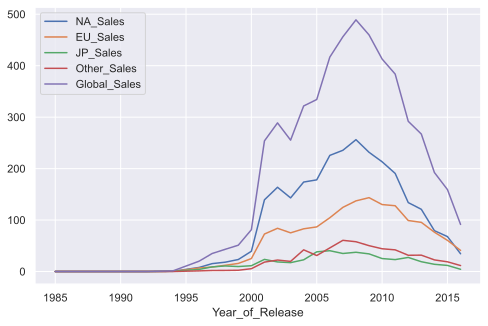

In [5]:
#Give me x, for each x in df.columns, if Sales is in x.
df[[x for x in df.columns if "Sales" in x] + ["Year_of_Release"]].groupby("Year_of_Release").sum().plot()

<Axes: xlabel='Year_of_Release'>

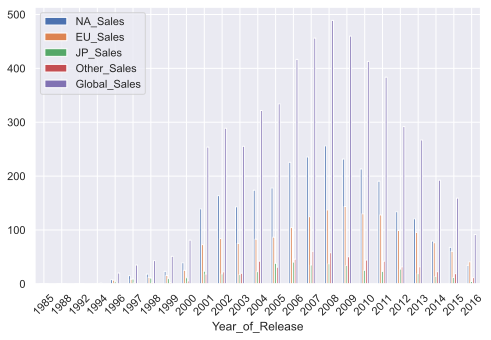

In [6]:
df[[x for x in df.columns if "Sales" in x] + ["Year_of_Release"]].groupby("Year_of_Release").sum().plot(kind="bar",rot=45)

Pairplot

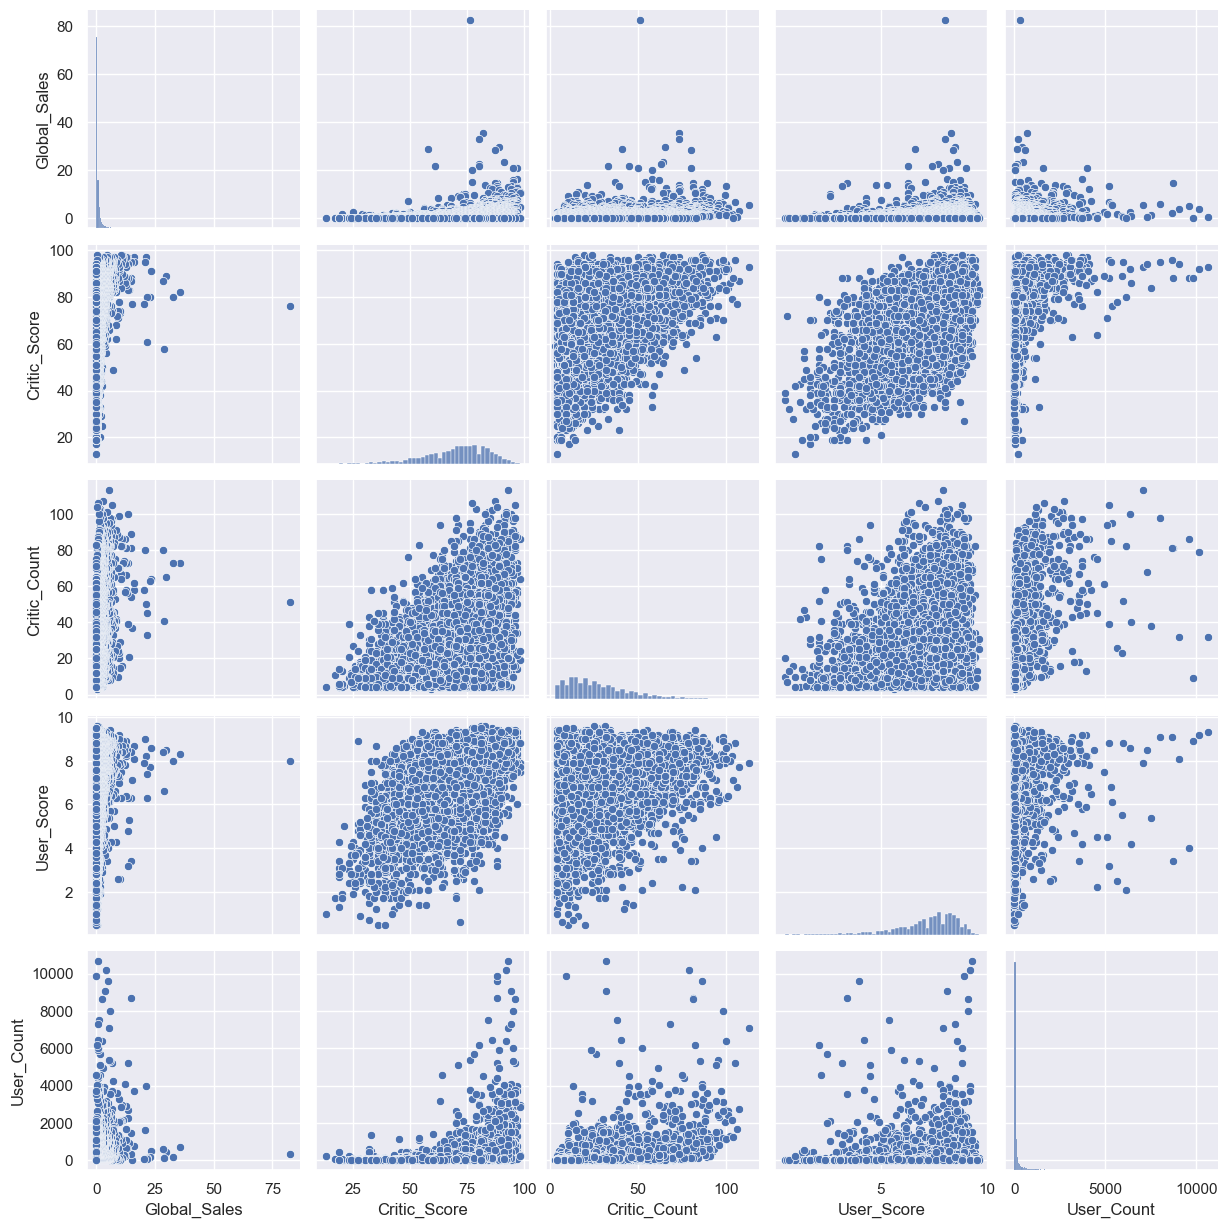

In [7]:
# `pairplot()` may become very slow with the SVG format
%config InlineBackend.figure_format = 'png'
sns.pairplot(
    df[["Global_Sales", "Critic_Score", "Critic_Count", "User_Score", "User_Count"]]
)

histplot

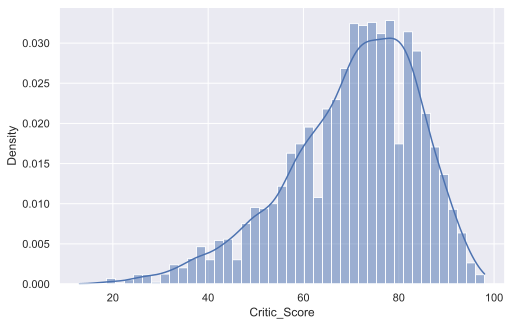

In [8]:
%config InlineBackend.figure_format = 'svg'
sns.histplot(df["Critic_Score"], kde=True, stat="density");

jointplot

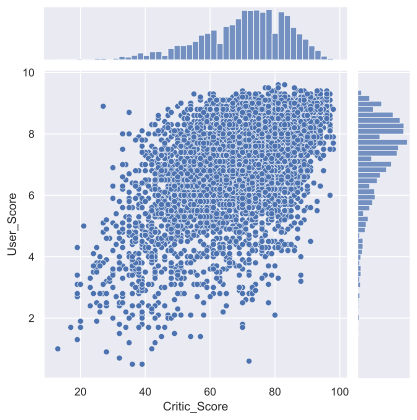

In [9]:
sns.jointplot(x="Critic_Score", y="User_Score", data=df, kind="scatter")

boxplot

<Axes: xlabel='Critic_Score', ylabel='Platform'>

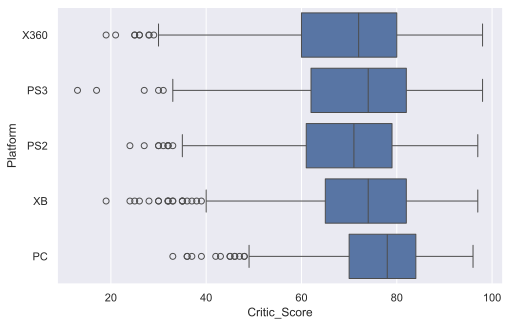

In [10]:
top_platforms = (
    df["Platform"].value_counts().sort_values(ascending=False).head(5).index.values
)
sns.boxplot(
    y="Platform",
    x="Critic_Score",
    data=df[df["Platform"].isin(top_platforms)],
    orient="h",
)

heatmap

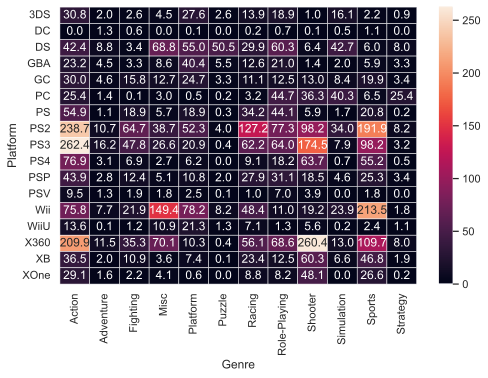

In [11]:
platform_genre_sales = (
    df.pivot_table(
        index="Platform", columns="Genre", values="Global_Sales", aggfunc="sum"
    )
    .fillna(0)
    .map(float)
)
sns.heatmap(platform_genre_sales, annot=True, fmt=".1f", linewidths=0.5);

4. Plotly

In [15]:
import plotly
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

init_notebook_mode(connected=True)

def plotly_depict_figure_as_iframe(fig, title="", width=800, height=500, plot_path="../../_static/plotly_htmls/" ): 
    #This is a helper method to visualize Plotly plots as Iframes in a Jupyter book.If you are running `jupyter-notebook`, you can just use iplot(fig)
    iplot(fig, show_link=False)

    #in jupiter Book, we save a plot offline and then render it with Iframe
    fig_path_path = f"{plot_path}/{title}.html"
    plot(fig, filename=fig_path_path, show_link=False, auto_open=False)
    display(IFrame(fig_path_path, width=width, height=height))

Lineplot

In [16]:
years_df = (
    df.groupby("Year_of_Release")[["Global_Sales"]].sum()
    .join(df.groupby("Year_of_Release")[["Name"]].count())
)
years_df.columns = ["Global_Sales", "Number_of_Games"]

In [17]:
#create a line (trace) for the global sales
trace0 = go.Scatter(x=years_df.index, y=years_df["Global_Sales"], name="Global Sales")

#create a line (trace) for the no of games released
trace1 = go.Scatter(x=years_df.index, y=years_df["Number_of_Games"], name="Number of games released")

#define the data array
data = [trace0, trace1]

#Set the title
layout = {"title" : "Statistics of video games"}

#create a figure and plot it
fig = go.Figure(data=data, layout=layout)

#in jupiter notebook the following should work
iplot(fig, show_link=False)

#in jupiter book we save the plot offline and then render it with Iframe
plotly_depict_figure_as_iframe(fig, title="topic2_part2_plot1")

FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\_static\\plotly_htmls\\topic2_part2_plot1.html'

In [ ]:
#As an option, you can save the plot in an html file:
# commented out as it produces a large in size file
#plotly.offline.plot(fig, filename="years_stats.html", show_link=False, auto_open=False);

------------------ Bar chart -----------------------------------------------

In [22]:
#Do calculations and prepare the dataset
platforms_df = (
    df.groupby("Platform")[["Global_Sales"]]
    .sum()
    .join(df.groupby("Platform")[["Name"]].count())
)
platforms_df.columns = ["Global_Sales", "Number_of_Games"]
platforms_df.sort_values("Global_Sales", ascending=False, inplace=True)
platforms_df.head()

,Global_Sales,Number_of_Games
Platform,,
PS2,945.97,1140
X360,853.30,858
PS3,784.30,769
Wii,658.98,479
DS,382.33,464
